In [ ]:
# standard
import os
import json
from pathlib import Path
from typing import List, Dict
import dill as pickle

# numeric
import numpy as np
import pandas as pd
from scipy import stats
from scipy.ndimage import gaussian_filter1d


# ml
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, pairwise_distances

# optuna
import optuna
from optuna.importance import get_param_importances

# plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# tedeous
from tedeous.data import Domain, Conditions, Equation
from tedeous.model import Model
from tedeous.optimizers.optimizer import Optimizer
from tedeous.models import (
    Fourier_embedding, SineLayer, CosineLayer, SineCosineLayer
)
from tedeous.callbacks import adaptive_lambda, cache, early_stopping, plot

from data_process import DataProcessor

In [84]:
def get_nearest_robots(coord_data, root_id, n=3):
    root_start = coord_data[root_id][0]  # начальная точка root
    all_starts = np.array([coords[0] for key, coords in coord_data.items()])
    keys = list(coord_data.keys())
    
    distances = pairwise_distances([root_start], all_starts).flatten()
    nearest_idx = np.argsort(distances)[1:n+1]  # исключаем сам root
    nearest_keys = [keys[i] for i in nearest_idx]
    
    return nearest_keys


In [85]:
def split_into_parts(t, num_parts=3):
    total_points = len(t)
    part_size = total_points // num_parts
    boundaries = [i*part_size for i in range(num_parts+1)]
    return boundaries


In [86]:
def collect_unique_terms(root="./output"):
    root = Path(root)
    unique_terms = set()

    for robot_dir in root.glob("robot_74"):
        for parts_dir in robot_dir.glob("1_parts"):
            for force_dir in parts_dir.glob("*_force"):

                # определяем n_parts из имени папки
                try:
                    n_parts = int(parts_dir.name.split("_")[0])
                except ValueError:
                    continue

                for part in range(1, n_parts + 1):
                    csv_path = force_dir / f"system_{part}.csv"
                    if not csv_path.exists():
                        continue

                    df = pd.read_csv(csv_path, index_col=0)
                    unique_terms.update(df.columns)

    return sorted(unique_terms)

terms = collect_unique_terms("./output")

print(f"Найдено {len(terms)} уникальных термов:")
for t in terms:
    print(t)

used_terms_x = {
'C_x',
'x{power: 1.0}_x',
'y{power: 1.0}_x',
'dx/dx0{power: 1.0}_x',
'd^2x/dx0^2{power: 1.0}_x',
'dy/dx0{power: 1.0}_x',
'd^2y/dx0^2{power: 1.0}_x',
't{power: 1.0, dim: 0.0}_x',
't{power: 2.0, dim: 0.0}_x',

'x{power: 1.0} * dx/dx0{power: 1.0}_x',
'y{power: 1.0} * dy/dx0{power: 1.0}_x',
'dx/dx0{power: 1.0} * dy/dx0{power: 1.0}_x',
'dx/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_x',
'dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x',
'dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x',
'd^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x',
'd^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_x',

'd^2x/dx0^2{power: 1.0} * d^2y/dx0^2{power: 1.0}_x',
'd^2x/dx0^2{power: 1.0} * x{power: 1.0}_x',
'd^2x/dx0^2{power: 1.0} * y{power: 1.0}_x',
'd^2y/dx0^2{power: 1.0} * dx/dx0{power: 1.0}_x',
'd^2y/dx0^2{power: 1.0} * x{power: 1.0}_x',
'dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_x',
'dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_x',
'dx/dx0{power: 1.0} * x{power: 1.0}_x',
'dx/dx0{power: 1.0} * y{power: 1.0}_x',

'x{power: 1.0} * t{power: 1.0, dim: 0.0}_x',
't{power: 1.0, dim: 0.0} * x{power: 1.0}_x',
't{power: 1.0, dim: 0.0} * y{power: 1.0}_x',
'x{power: 1.0} * cos{power: 1.0, dim: 0.0}_x',
'y{power: 1.0} * dx/dx0{power: 1.0}_x',
'y{power: 1.0} * x{power: 1.0}_x',
'd^2x/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x',
'x{power: 1.0} * dy/dx0{power: 1.0}_x',
'x{power: 1.0} * y{power: 1.0}_x'

}

used_terms_y = {
    'C_y',
'x{power: 1.0}_y',
'y{power: 1.0}_y',
'dx/dx0{power: 1.0}_y',
'd^2x/dx0^2{power: 1.0}_y',
'dy/dx0{power: 1.0}_y',
'd^2y/dx0^2{power: 1.0}_y',
't{power: 1.0, dim: 0.0}_y',
't{power: 2.0, dim: 0.0}_y',

'y{power: 1.0} * d^2y/dx0^2{power: 1.0}_y',
'dy/dx0{power: 1.0} * x{power: 1.0}_y',
'dy/dx0{power: 1.0} * dx/dx0{power: 1.0}_y',
'dy/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_y',
'd^2y/dx0^2{power: 1.0} * d^2x/dx0^2{power: 1.0}_y',
't{power: 1.0, dim: 0.0} * d^2y/dx0^2{power: 1.0}_y',
't{power: 2.0, dim: 0.0} * y{power: 1.0}_y',
'dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y',
'dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_y',

'd^2x/dx0^2{power: 1.0} * cos{power: 1.0, dim: 0.0}_y',
'd^2x/dx0^2{power: 1.0} * dy/dx0{power: 1.0}_y',
'd^2y/dx0^2{power: 1.0} * cos{power: 1.0, dim: 0.0}_y',
'd^2y/dx0^2{power: 1.0} * x{power: 1.0}_y',
'd^2y/dx0^2{power: 1.0} * y{power: 1.0}_y',
'dx/dx0{power: 1.0} * x{power: 1.0}_y',
'dx/dx0{power: 1.0} * y{power: 1.0}_y',
'dy/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y',
'dy/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_y',
'dy/dx0{power: 1.0} * y{power: 1.0}_y',
't{power: 1.0, dim: 0.0} * y{power: 1.0}_y',
'x{power: 1.0} * dy/dx0{power: 1.0}_y',
'x{power: 1.0} * y{power: 1.0}_y',
'y{power: 1.0} * dy/dx0{power: 1.0}_y',
'y{power: 1.0} * x{power: 1.0}_y',

'd^2x/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y', 
'd^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 
'd^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y'

}

all_used_terms = used_terms_x.union(used_terms_y)
unused_terms = set(terms) - all_used_terms
unused_terms = sorted(unused_terms)

# термы, оканчивающиеся на _x
unused_x = [t for t in unused_terms if t.endswith("_x")]

# термы, оканчивающиеся на _y
unused_y = [t for t in unused_terms if t.endswith("_y")]

print("Неиспользуемые термы _x:")
print(unused_x)

print("\nНеиспользуемые термы _y:")
print(unused_y)


Найдено 22 уникальных термов:
C_x
C_y
d^2x/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x
d^2x/dx0^2{power: 1.0} * x{power: 1.0}_x
d^2x/dx0^2{power: 1.0}_x
d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_y
d^2y/dx0^2{power: 1.0} * x{power: 1.0}_y
d^2y/dx0^2{power: 1.0}_x
d^2y/dx0^2{power: 1.0}_y
dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x
dx/dx0{power: 1.0} * x{power: 1.0}_x
dx/dx0{power: 1.0}_x
dy/dx0{power: 1.0} * x{power: 1.0}_y
dy/dx0{power: 1.0}_x
dy/dx0{power: 1.0}_y
t{power: 1.0, dim: 0.0}_y
x{power: 1.0} * dx/dx0{power: 1.0}_x
x{power: 1.0}_x
x{power: 1.0}_y
y{power: 1.0} * dy/dx0{power: 1.0}_y
y{power: 1.0}_x
y{power: 1.0}_y
Неиспользуемые термы _x:
[]

Неиспользуемые термы _y:
[]


In [87]:
# ================================
# === SYMBOLIC SYSTEM BUILDER ===
# ================================
class RobotSystemBuilder:
    """
    Constructs symbolic differential equation systems for robot trajectories.

    Responsibilities:
    - load discovered coefficients from CSV files
    - generate Monte Carlo perturbations of coefficients
    - convert coefficient tables into Tedeous-compatible equation dictionaries
    """
    def __init__(self, robot_id: int, num_parts: int = 3, mc_samples: int = 10, force = 'without', input_dir = './output'):
        self.robot_id = robot_id
        self.num_parts = num_parts
        self.mc_samples = mc_samples
        self.force = force
        self.mc_id=0
        self.robot_dir = Path(input_dir)/f"robot_{self.robot_id}/{self.num_parts}_parts/{self.force}_force"


    def drop_zero_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Removes columns that contain only zero values."""
        return df.loc[:, (df != 0).any(axis=0)]
    
    def threshold_coefficients(self,df: pd.DataFrame, thr: float = 1e-4) -> pd.DataFrame:
        df_clean = df.copy()
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        df_clean[numeric_cols] = df_clean[numeric_cols].where(
            np.abs(df_clean[numeric_cols]) >= thr, 
            0.0
        )
        return df_clean

    def construct_equation_dict(self, new_coeff: pd.DataFrame, grid):
        """Converts a coefficient row into symbolic equation dictionaries."""
        equations = []
        for _, row in new_coeff.iterrows():
            
            first_dict ={
            # --- Terms for X equation ---
            'C_x': {'coeff': row.get('C_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'x_x': {'coeff': row.get('x{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
            'y_x': {'coeff': row.get('y{power: 1.0}_x', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
            'dx/dt_x': {'coeff': row.get('dx/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
            'd^2x/dt^2_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
            'dy/dt_x': {'coeff': row.get('dy/dx0{power: 1.0}_x', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
            'd^2y/dt^2_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_x', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
            't_x': {'coeff': row.get('t{power: 1.0, dim: 0.0}_x', 0)*grid, 'term': [[None]], 'pow': [0], 'var': [0]},
            't^2_x': {'coeff': row.get('t{power: 2.0, dim: 0.0}_x', 0)*grid**2, 'term': [[None]], 'pow': [0], 'var': [0]},

            # --- Composite terms for X equation ---
            'x*dx/dt_x': {'coeff': row.get('x{power: 1.0} * dx/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [0, 0]},
            'y*dy/dt_x': {'coeff': row.get('y{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[None], [0]],
                          'pow': [1, 1], 'var': [1, 1]},
            'dx/dt*dy/dt_x': {'coeff': row.get('dx/dx0{power: 1.0} * dy/dx0{power: 1.0}_x', 0), 'term': [[0], [0]],
                              'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*d^2x/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 0]},
            'dx/dt*d^2y/dt^2_x': {'coeff': row.get('dx/dx0{power: 1.0} * d^2y/dx0^2{power: 1.0}_x', 0),
                                  'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            'dx/dt*t_x': {'coeff': row.get('dx/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0)*grid, 'term': [[0], [None]], 
                          'pow': [1, 0], 'var': [0, 0]},
            'd^2y/dt^2*t_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0)*grid, 
                              'term': [[0, 0], [None]], 'pow': [1, 0], 'var': [1, 0]},
            'd^2y/dt^2*sin_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_x', 0)*torch.sin(grid), 
                                'term': [[0, 0], [None]], 'pow': [1, 0], 'var': [1, 0]},
            
            'd^2x/dt^2*d^2y/dt^2_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * d^2y/dx0^2{power: 1.0}_x', 0),
                                'term': [[0, 0], [0, 0]], 'pow': [1, 1], 'var': [0, 1]},
            'd^2x/dt^2*x_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * x{power: 1.0}_x', 0),
                                'term': [[0,0],[None]], 'pow': [1, 1], 'var': [0, 0]},
            'd^2x/dt^2*y_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * y{power: 1.0}_x', 0),
                                'term': [[0,0],[None]], 'pow': [1, 1], 'var': [0, 1]},
            'd^2y/dt^2*dx/dt_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * dx/dx0{power: 1.0}_x', 0),
                                'term': [[0,0],[0]], 'pow': [1, 1], 'var': [1, 0]},
            'd^2y/dt^2*x_x': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * x{power: 1.0}_x', 0),
                                'term': [[0,0],[None]], 'pow': [1,1 ], 'var': [1, 0]},
            'dx/dt*cos_x': {'coeff': row.get('dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_x', 0)*torch.cos(grid), 
                            'term': [[0],[None]], 'pow': [1, 0], 'var': [0, 0]},
            'dx/dt*sin_x': {'coeff': row.get('dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_x', 0)*torch.sin(grid), 
                            'term': [[0],[None]], 'pow': [1, 0], 'var': [0, 0]},
            'dx/dt*x_x': {'coeff': row.get('dx/dx0{power: 1.0} * x{power: 1.0}_x', 0),
                                'term': [[0],[None]], 'pow': [1, 1], 'var': [0, 0]},
            'dx/dt*y_x': {'coeff': row.get('dx/dx0{power: 1.0} * y{power: 1.0}_x', 0),
                                'term': [[0],[None]], 'pow': [1, 1], 'var': [0, 1]},
            'x*t_x': {'coeff': row.get('x{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0)*grid, 
                      'term': [[None],[None]], 'pow': [1, 0], 'var': [0, 0]},
            't*x_x': {'coeff': row.get('t{power: 1.0, dim: 0.0} * x{power: 1.0}_x', 0)*grid, 
                      'term': [[None],[None]], 'pow': [0, 1], 'var': [0, 0]},
            't*y_x': {'coeff': row.get('t{power: 1.0, dim: 0.0} * y{power: 1.0}_x', 0)*grid, 
                      'term': [[None],[None]], 'pow': [0, 1], 'var': [0, 1]},
            'x*cos_x': {'coeff': row.get('x{power: 1.0} * cos{power: 1.0, dim: 0.0}_x', 0)*torch.cos(grid), 
                        'term': [[None],[None]], 'pow': [1, 0], 'var': [0, 0]},
            'y*dx/dt_x': {'coeff': row.get('y{power: 1.0} * dx/dx0{power: 1.0}_x', 0),
                                'term': [[None],[0]], 'pow': [1, 1], 'var': [1, 0]},
            'y*x_x': {'coeff': row.get('y{power: 1.0} * x{power: 1.0}_x', 0),
                                'term': [[None],[None]], 'pow': [1, 1], 'var': [1, 0]},
            'd^2x/dt^2*t_x': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_x', 0)*grid, 
                               'term': [[0, 0],[None]], 'pow': [1, 0], 'var': [0, 0]},
            'x*dy/dt_x': {'coeff': row.get('x{power: 1.0} * dy/dx0{power: 1.0}_x', 0),
                               'term': [[None],[0]], 'pow': [1, 1], 'var': [0, 1]},
            'x*y_x': {'coeff': row.get('x{power: 1.0} * y{power: 1.0}_x', 0),
                               'term': [[None],[None]], 'pow': [1, 1], 'var': [0, 1]}
           }


            second_dict ={
                # --- Terms for Y equation ---
                'C_y': {'coeff': row.get('C_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
                'x_y': {'coeff': row.get('x{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [0]},
                'y_y': {'coeff': row.get('y{power: 1.0}_y', 0), 'term': [[None]], 'pow': [1], 'var': [1]},
                'dx/dt_y': {'coeff': row.get('dx/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [0]},
                'd^2x/dt^2_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [0]},
                'dy/dt_y': {'coeff': row.get('dy/dx0{power: 1.0}_y', 0), 'term': [[0]], 'pow': [1], 'var': [1]},
                'd^2y/dt^2_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[0, 0]], 'pow': [1], 'var': [1]},
                't_y': {'coeff': row.get('t{power: 1.0, dim: 0.0}_y', 0)*grid, 'term': [[None]], 'pow': [0], 'var': [0]}, 
                't^2_y': {'coeff': row.get('t{power: 2.0, dim: 0.0}_y', 0)*grid**2, 'term': [[None]], 'pow': [0], 'var': [0]},


                # --- Composite terms for Y equation ---
                'y*d^2y/dt^2_y': {'coeff': row.get('y{power: 1.0} * d^2y/dx0^2{power: 1.0}_y', 0), 'term': [[None], [0, 0]],
                                'pow': [1, 1], 'var': [1, 1]},
                'dy/dt*x_y': {'coeff': row.get('dy/dx0{power: 1.0} * x{power: 1.0}_y', 0), 'term': [[0], [None]],
                            'pow': [1, 1], 'var': [1, 0]},
                'dy/dt*dx/dt_y': {'coeff': row.get('dy/dx0{power: 1.0} * dx/dx0{power: 1.0}_y', 0), 'term': [[0], [0]],
                                'pow': [1, 1], 'var': [1, 0]},
                'dy/dt*d^2x/dt^2_y': {'coeff': row.get('dy/dx0{power: 1.0} * d^2x/dx0^2{power: 1.0}_y', 0),
                                    'term': [[0], [0, 0]], 'pow': [1, 1], 'var': [1, 0]},
                'd^2y/dt^2_y*d^2x/dt^2': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * d^2x/dx0^2{power: 1.0}_y', 0),
                                        'term': [[0, 0], [0, 0]], 'pow': [1, 1], 'var': [1, 0]},
                't*d^2y/dt^2_y': {'coeff': row.get('t{power: 1.0, dim: 0.0} * d^2y/dx0^2{power: 1.0}_y', 0)*grid, 
                                  'term': [[None], [0, 0]], 'pow': [0, 1], 'var': [0, 1]},
                't^2*y_y': {'coeff': row.get('t{power: 2.0, dim: 0.0} * y{power: 1.0}_y', 0)*grid**2, 
                            'term': [[None], [None]], 'pow': [0, 1], 'var': [0, 1]},
                'dx/dt*sin_y': {'coeff': row.get('dx/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0)*torch.sin(grid), 
                                'term': [[0], [None]], 'pow': [1, 0], 'var': [0, 0]},
                'dx/dt*cos_y': {'coeff': row.get('dx/dx0{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0)*torch.cos(grid), 
                                'term': [[0], [None]], 'pow': [1, 0], 'var': [0, 0]},
                
                'd^2x/dt^2*cos_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0)*torch.cos(grid), 
                                    'term': [[0,0], [None]], 'pow': [1, 0], 'var': [0, 0]},
                'd^2x/dt^2*dy/dt_y': {'coeff': row.get('d^2x/dx0^2{power: 1.0} * dy/dx0{power: 1.0}_y', 0),
                                        'term': [[0,0], [0]], 'pow': [1, 1], 'var': [0, 1]},
                'd^2y/dt^2*cos_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * cos{power: 1.0, dim: 0.0}_y', 0)*torch.cos(grid), 
                                    'term': [[0,0], [None]], 'pow': [1, 0], 'var': [1, 0]},
                'd^2y/dt^2*x_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * x{power: 1.0}_y', 0),
                                        'term': [[0,0], [None]], 'pow': [1, 1], 'var': [1, 0]},
                'd^2y/dt^2*y_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * y{power: 1.0}_y', 0),
                                        'term': [[0,0], [None]], 'pow': [1, 1], 'var': [1, 1]},
                'dx/dt*x_y': {'coeff': row.get('dx/dx0{power: 1.0} * x{power: 1.0}_y', 0),
                                        'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 0]},
                'dx/dt*y_y': {'coeff': row.get('dx/dx0{power: 1.0} * y{power: 1.0}_y', 0),
                                        'term': [[0], [None]], 'pow': [1, 1], 'var': [0, 1]},
                'dy/dt*sin_y': {'coeff': row.get('dy/dx0{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0)*torch.sin(grid), 
                                'term': [[0], [None]], 'pow': [1, 0], 'var': [1, 0]},
                'dy/dt*t_y': {'coeff': row.get('dy/dx0{power: 1.0} * t{power: 1.0, dim: 0.0}_y', 0)*grid, 
                              'term': [[0], [None]], 'pow': [1, 0], 'var': [1, 0]},
                'dy/dt*y_y': {'coeff': row.get('dy/dx0{power: 1.0} * y{power: 1.0}_y', 0),
                                        'term': [[0], [None]], 'pow': [1, 1], 'var': [1, 1]},
                't*y_y': {'coeff': row.get('t{power: 1.0, dim: 0.0} * y{power: 1.0}_y', 0)*grid, 
                          'term': [[None], [None]], 'pow': [0, 1], 'var': [0, 1]},
                'x*dy/dt_y': {'coeff': row.get('x{power: 1.0} * dy/dx0{power: 1.0}_y', 0),
                                        'term': [[None], [0]], 'pow': [1, 1], 'var': [0, 1]},
                'x*y_y': {'coeff': row.get('x{power: 1.0} * y{power: 1.0}_y', 0),
                                        'term': [[None], [None]], 'pow': [1, 1], 'var': [0, 1]},
                'y*dy/dt_y': {'coeff': row.get('y{power: 1.0} * dy/dx0{power: 1.0}_y', 0),
                                        'term': [[None], [0]], 'pow': [1, 1], 'var': [1, 1]},
                'y*x_y': {'coeff': row.get('y{power: 1.0} * x{power: 1.0}_y', 0),
                                        'term': [[None], [None]], 'pow': [1, 1], 'var': [1, 0]},
                'd^2y/dt^2*sin_y': {'coeff': row.get('d^2y/dx0^2{power: 1.0} * sin{power: 1.0, dim: 0.0}_y', 0)*torch.sin(grid), 
                                    'term': [[0,0], [None]], 'pow': [1, 0], 'var': [1, 0]},
                'd^2x/dt^2*t_y':{'coeff': row.get('d^2x/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y',0)*grid,
                                 'term':[[0,0],[None]],'pow':[1,0], 'var':[0,0]},
                'd^2y/dt^2*t_y':{'coeff': row.get('d^2y/dx0^2{power: 1.0} * t{power: 1.0, dim: 0.0}_y',0)*grid,
                                 'term':[[0,0],[None]],'pow':[1,0], 'var':[1,0]},

            }

            def coeff_nonzero(coeff):
                if isinstance(coeff, (int, float)):
                    return abs(coeff) > 1e-3  # threshold for non-zero coefficients
                elif isinstance(coeff, torch.Tensor):
                    return torch.any(torch.abs(coeff) > 1e-3)
                else:
                    raise TypeError(f"Unsupported coeff type: {type(coeff)}")

            first_dict = {k: v for k, v in first_dict.items() if coeff_nonzero(v['coeff'])}
            second_dict = {k: v for k, v in second_dict.items() if coeff_nonzero(v['coeff'])}
            equations.append((first_dict, second_dict))
        return equations


    def build_mc_system(self):
        """Builds full symbolic systems for all trajectory parts
        using Monte Carlo sampling of coefficients."""
        for part in range(1, self.num_parts+1):
            csv_path =  self.robot_dir /f"system_{part}.csv"
            df = pd.read_csv(csv_path)
            df = self.threshold_coefficients(df, thr=1e-4)
            df = self.drop_zero_columns(df)
            mc_rows = []
            for mc_idx in range(self.mc_samples):
                row = {}
                for col in df.columns:
                    std_dev = df[col].std()
                    min_val = df[col].min()
                    max_val = df[col].max()
                    mean_val = df[col].iloc[mc_idx%len(df)]
                    sample = mean_val + np.random.normal(scale=std_dev * 0.01 * (mc_idx//len(df)))
                    row[col] = np.clip(sample, min_val, max_val)

                mc_rows.append(row) 

            mc_df_all = pd.DataFrame(mc_rows)
            mc_path = os.path.join(self.robot_dir, f'mc_system_{part}.csv')
            #mc_df_all.to_csv(mc_path, index=False)
        return 


In [93]:
robot_id = 74
num_parts = 1
num_mc_samples = 10 
n_trials=10
epoch_trained = 1000
epoch_pretrained = 1500
force = 'less_sigma'
CUT_NUMBER = 200 #2750
input_dir = './output'
with open('data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file:
    raw_data = pickle.load(file)
processor = DataProcessor(raw_data)
processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()
datas = np.load('particle_coordinates.npz')
loaded_arr1 = datas['a']
loaded_arr2 = datas['b']
normalized_coord_data, key = processor.transform_new_robot(loaded_arr1[:200000:1000], loaded_arr2[:200000:1000])

In [ ]:
#robot_id = key
key

84

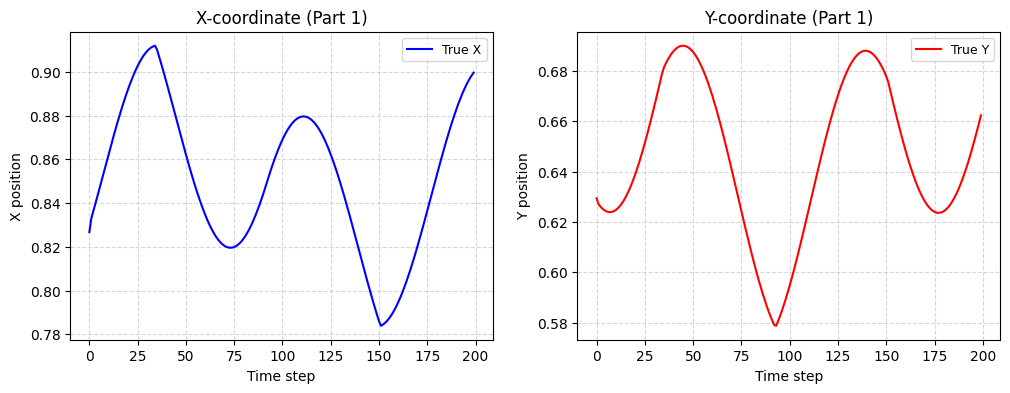

In [ ]:
x = np.array([coord[0] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
y = np.array([coord[1] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
t = np.arange(len(x))
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t, x, 'b-', label='True X')
plt.title(f'X-coordinate (Part {0 + 1})', fontsize=12)
plt.xlabel("Time step", fontsize=10)
plt.ylabel("X position", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)

plt.subplot(1, 2, 2)
plt.plot(t, y, 'r-', label='True Y')
plt.title(f'Y-coordinate (Part {0 + 1})', fontsize=12)
plt.xlabel("Time step", fontsize=10)
plt.ylabel("Y position", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)


In [ ]:
y[0]

0.6293577981651376

[I 2026-02-17 18:19:03,643] A new study created in memory with name: no-name-24d014f2-ab54-46c1-a8e7-490630f133c0


74

🌌 Monte Carlo sample1/10

=== Optimization of parameters for the part 1/1 ===
0 199 199
{'C_x': {'coeff': 0.0119969330038471, 'term': [[None]], 'pow': [1], 'var': [0]}, 'x_x': {'coeff': -0.0136017468497025, 'term': [[None]], 'pow': [1], 'var': [0]}, 'd^2x/dt^2_x': {'coeff': -1.0, 'term': [[0, 0]], 'pow': [1], 'var': [0]}}
{'d^2y/dt^2_y': {'coeff': 0.853038394774625, 'term': [[0, 0]], 'pow': [1], 'var': [1]}, 'd^2y/dt^2*x_y': {'coeff': -1.0, 'term': [[0, 0], [None]], 'pow': [1, 1], 'var': [1, 0]}}
ok
ok
[2026-02-17 18:19:03.656221] initial (min) loss is 1221.5771484375
[2026-02-17 18:19:04.046503] Step = 100 loss = 101.607880 normalized loss line= 0.027469x+5.596189. There was 0 stop dings already.
[2026-02-17 18:19:04.507764] Step = 200 loss = 1.845892 normalized loss line= 1.512068x+308.044576. There was 0 stop dings already.
[2026-02-17 18:19:04.919596] Step = 300 loss = 0.335383 normalized loss line= -7.315869x+1633.338204. There was 0 stop dings already.
[2026-02-17 18:19:05.33

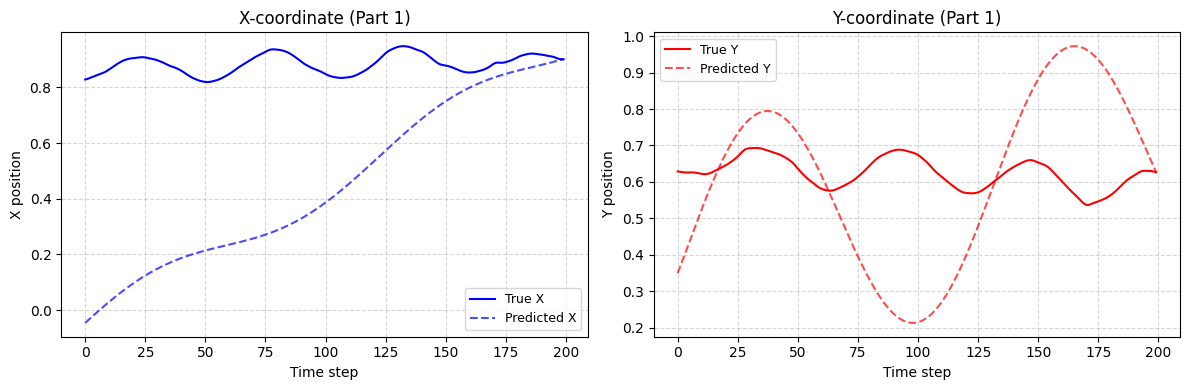

[W 2026-02-17 18:19:09,774] Trial 0 failed with parameters: {'L': 127.76090735506574, 'M': 1, 'num_layers': 1} because of the following error: ValueError('XA must be a 2-dimensional array.').
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Active_Matter/lib/python3.11/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/7j/xp9cdfy928x66ht1lmrmcs4c0000gn/T/ipykernel_44584/2467019967.py", line 360, in objective
    frech_vec=frechet_dist(pred_vec,
              ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/Active_Matter/lib/python3.11/site-packages/similaritymeasures/similaritymeasures.py", line 488, in frechet_dist
    c = distance.cdist(exp_data, num_data, metric='minkowski', p=p)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/Active_Matter/lib/python3.11/site-packages/scipy/spatial/distance.py", line 3111, in cdist
 

[0.82675709 0.8298397  0.83415536 0.83723798 0.83908755 0.84401973
 0.84771887 0.84956843 0.85326757 0.85819975 0.86436498 0.86991369
 0.87607891 0.88224414 0.88779285 0.89272503 0.89704069 0.9001233
 0.9025894  0.90382244 0.90505549 0.90505549 0.90690506 0.9081381
 0.90937115 0.90752158 0.90628853 0.90320592 0.90135635 0.90073983
 0.89765721 0.89334155 0.89087546 0.8865598  0.88224414 0.87669544
 0.87422935 0.8729963  0.86868064 0.86436498 0.86004932 0.85450062
 0.84771887 0.84217016 0.83662145 0.8323058  0.82922318 0.82490752
 0.82244143 0.82059186 0.81874229 0.81812577 0.81935882 0.82182491
 0.82305795 0.82614057 0.8298397  0.83292232 0.83847102 0.84340321
 0.84771887 0.85388409 0.86004932 0.86683107 0.87361282 0.87792848
 0.88286067 0.88840937 0.89395808 0.89950678 0.90505549 0.91060419
 0.91491985 0.91861899 0.92293465 0.92725031 0.93279901 0.93711467
 0.93711467 0.93588163 0.93588163 0.93403206 0.93279901 0.93033292
 0.92663379 0.92231813 0.91738594 0.91122072 0.90505549 0.898273

ValueError: XA must be a 2-dimensional array.

In [102]:
# =========================================
# === TRAJECTORY SOLVER (PINN) ===
# =========================================
class RobotTrajectorySolver:
    """
    Solves robot trajectories using Physics-Informed Neural Networks (PINNs).

    The solver:
    - splits the trajectory into temporal parts
    - solves each part sequentially
    - enforces continuity via boundary conditions
    - supports Optuna-based hyperparameter tuning
    - handles Monte Carlo systems of discovered equations
    """
    def __init__(self, x, y, t, robot_id=78,num_parts=4,
                  epochs=500, lambda_operator=100, lambda_bound=1,
                 lr=1e-4, device='cpu', mode='autograd',
                 L=1/4, M=1, force='without', input_dir='./output',
                 num_layers=5, hidden_dim=100, activation_type="sine"): 
        self.activation_type = activation_type
        self.x = x
        self.y = y
        self.t = t
        self.num_parts = num_parts
        self.robot_id = robot_id
        self.force=force
        self.epochs = epochs

        self.robot_dir = Path(input_dir)/f"robot_{self.robot_id}/{self.num_parts}_parts/{self.force}_force"
        
        self.lambda_operator = lambda_operator
        self.lambda_bound = lambda_bound
        self.lr = lr
        self.device = device
        self.mode = mode
        self.L = L
        self.M = M
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.total_points = len(t)
        self.part_size = self.total_points // num_parts
        self.boundaries_idx = [i * self.part_size for i in range(num_parts + 1)]

        self.all_solutions = []

    def _prepare_boundaries(self, part, t_part,solution):
        """Construct Dirichlet boundary conditions for a trajectory segment."""
        boundaries = Conditions()
        indices = [0,len(t_part) - 1] #len(t_part)//2,
        
        if part == 0:
            for idx in indices:
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx]]),
                    value=torch.tensor([[self.smooth_x[idx]]]).float(),
                    var=0
                )
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx]]),
                    value=torch.tensor([[self.smooth_y[idx]]]).float(),
                    var=1
                )
        else:
            prev_sol = solution[-1]
            # continuity with previous solution
            boundaries.dirichlet(
                bnd=torch.Tensor([0.0]),
                value=torch.tensor([[prev_sol[0]]]).float(),
                var=0
            )
            boundaries.dirichlet(
                bnd=torch.Tensor([0.0]),
                value=torch.tensor([[prev_sol[1]]]).float(),
                var=1
            )

            idx = indices[1]
            global_idx = self.boundaries_idx[part] + idx
            boundaries.dirichlet(
                bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                value=torch.tensor([[self.smooth_x[global_idx]]]).float(),
                var=0
            )
            boundaries.dirichlet(
                bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                value=torch.tensor([[self.smooth_y[global_idx]]]).float(),
                var=1
            )
            if len(indices) > 2:
                idx = indices[2]
                global_idx = self.boundaries_idx[part] + idx
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                    value=torch.tensor([[self.smooth_x[global_idx]]]).float(),
                    var=0
                )
                boundaries.dirichlet(
                    bnd=torch.Tensor([t_part[idx] - t_part[0]]),
                    value=torch.tensor([[self.smooth_y[global_idx]]]).float(),
                    var=1
                )
        return boundaries

    def _build_network(self):
        """Build neural network with configurable activation:
        - Fourier embedding"""
        layers = []
        out_features = 0
        FFL = Fourier_embedding(L=[self.L], M=[self.M])
        layers = [FFL]
        out_features = FFL.out_features
        layers.append(nn.Linear(max(1,out_features), self.hidden_dim))
        #layers.append(CosineLayer(FFL.out_features, self.hidden_dim, is_first=True, omega_0=self.omega_0))#,omega_1=self.omega_1 ))
    
        for _ in range(self.num_layers - 1):
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(self.hidden_dim, 2))
        net = nn.Sequential(*layers).to(self.device)
        return net

    def _scale_eq_by_time(self, eq_dict, T):
        """
        Scale PDE coefficients according to time normalization.

        If time is rescaled t → t/T, then:
            d^k/dt^k → (1/T)^k
        """
        scaled = {}

        for name, data in eq_dict.items():
            data_new = data.copy()
            print(name, data_new)
            

            # Count derivative order
            order = 0
            for term in data['term']:
                if term[0] is not None:  # производная
                    order += len(term[0])
                if (len(term)==2) and (term[1] is not None):  # производная
                    order += len(term[1])
                

            data_new['coeff'] *= (1.0 / T) ** order
            scaled[name] = data_new

        return scaled

    def _train_part(self, part, solution,builder, prev_state_dict=None, lr=1e-4):
        """
        Train PINN for one temporal segment.
        """
        self.lr = lr
        with open(self.robot_dir/f"part_{part+1}_system_best_params.json", "r") as f:
            params = json.load(f)
        self.sigma = params.get("best_params", {}).get("sigma")
        self.smooth_x = gaussian_filter1d(self.x, sigma=self.sigma)
        self.smooth_y = gaussian_filter1d(self.y, sigma=self.sigma)

        t_part = self.t[self.boundaries_idx[part]:self.boundaries_idx[part + 1]]
        t_part_norm = (t_part - t_part.min()) #/ (t_part.max() - t_part.min())
        #self.T = (t_part.max() - t_part.min())
        domain = Domain()
        self.lenght_dom=10
        domain.variable('t', [t_part_norm[0], t_part_norm[-1]], (len(t_part_norm)-1)*self.lenght_dom)
        print(t_part_norm[0], t_part_norm[-1], (len(t_part_norm)-1))  # теперь t всегда в [0,1][0.0, 1.0]
        grid = domain.variable_dict['t'].reshape(-1,1)

        csv_path = self.robot_dir / f"mc_system_{part+1}.csv"
        df = pd.read_csv(csv_path)
        mc_row = df.iloc[builder.mc_idx:builder.mc_idx+1]
        eqs_part = builder.construct_equation_dict(pd.DataFrame([mc_row.iloc[0]]), grid)

        eq = Equation()
        for first_dict, second_dict in eqs_part:
            eq.add(first_dict)#(self._scale_eq_by_time(first_dict, self.T))
            print(first_dict)
            eq.add(second_dict)#(self._scale_eq_by_time(second_dict, self.T))
            print(second_dict)

        boundaries = self._prepare_boundaries(part, t_part_norm, solution)

        net = self._build_network()
        if prev_state_dict is not None:
            net.load_state_dict(prev_state_dict)
            print("🔁 Загружены лучшие веса для дообучения этой части")


        cb_es = early_stopping.EarlyStopping(eps=1e-5,
                                     loss_window=300,
                                     no_improvement_patience=500,
                                     patience=1,
                                     info_string_every=100,
                                     randomize_parameter=1e-5)

        img_dir = self.robot_dir / 'SODE_img'

        #cb_cache = cache.Cache(cache_verbose=True, model_randomize_parameter=1e-5)

        cb_plots = plot.Plots(save_every=100, print_every=None, img_dir=img_dir)


        model = Model(net, domain, eq, boundaries)
        model.compile(self.mode,
                    lambda_operator=self.lambda_operator,
                    lambda_bound=self.lambda_bound)
        optimizer = Optimizer('Adam', {'lr': self.lr})
        model.train(optimizer, epochs=self.epochs, callbacks=[cb_es, cb_plots])
        sol = net(grid).detach().cpu().numpy()
        best_state_dict = net.state_dict()
        return sol, best_state_dict

    def plot_optuna_basic(self, study, metric_name="MAPE", title=None):
        """Plot Optuna study results: optimization history and parameter importance."""
        trials = [t for t in study.trials if t.value is not None]
        trial_nums = [t.number for t in trials]
        values = [t.value for t in trials]

        fig, axs = plt.subplots(1, 2, figsize=(14, 4))

        axs[0].plot(trial_nums, values, marker='o')
        axs[0].set_title(f"Optimization history ({metric_name})")
        axs[0].set_xlabel("Trial")
        axs[0].set_ylabel(metric_name)
        axs[0].grid(True)

        importances = get_param_importances(study)
        axs[1].barh(
            list(importances.keys()),
            list(importances.values())
        )
        axs[1].set_title("Parameter importance")
        axs[1].invert_yaxis()

        if title:
            fig.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()

    def visualize_part(self, part_idx, pred):
        """Visualize predicted vs true trajectory for a single segment."""

        start = self.boundaries_idx[part_idx]
        end = self.boundaries_idx[part_idx + 1]

        true_x = self.smooth_x[start:end]
        true_y = self.smooth_y[start:end]
        t_part = self.t[start:end]
        pred_x = pred[:, 0]
        pred_y = pred[:, 1]

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(t_part[:len(pred_x)], true_x[:len(pred_x)], 'b-', label='True X')
        plt.plot(t_part[:len(pred_x)], pred_x, 'b--', alpha=0.7, label='Predicted X')
        plt.title(f'X-coordinate (Part {part_idx + 1})', fontsize=12)
        plt.xlabel("Time step", fontsize=10)
        plt.ylabel("X position", fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=9)

        plt.subplot(1, 2, 2)
        plt.plot(t_part[:len(pred_y)], true_y[:len(pred_y)], 'r-', label='True Y')
        plt.plot(t_part[:len(pred_y)], pred_y, 'r--', alpha=0.7, label='Predicted Y')
        plt.title(f'Y-coordinate (Part {part_idx + 1})', fontsize=12)
        plt.xlabel("Time step", fontsize=10)
        plt.ylabel("Y position", fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

def tune_part(part_idx, solver,solution_prev, n_trials=10, prev_best_params=None):
    """Tune hyperparameters with Optuna for a single trajectory segment.
    
    Strategy:
    - Suggest network parameters (activation, layers, Fourier embedding)
    - Train the segment using PINN
    - Evaluate objective function (combined MAPE + RMSE)
    - Track best weights for final training
    """
    best_state_dict = None
    def objective(trial):
        nonlocal best_state_dict
        max_L = 200.0
        list_M = [ 1,2, 3,4]
        L = trial.suggest_float("L", 100.0, max_L)
        M = trial.suggest_categorical("M", list_M)
        num_layers = trial.suggest_int("num_layers", 1, 1)
        hidden_dim=100
        solver.L = L
        solver.M = M
        solver.num_layers = num_layers
        solver.hidden_dim = hidden_dim

        
        pred, state_dict = solver._train_part(part_idx,solution_prev,builder)
        pred=pred[::solver.lenght_dom]
        solver.visualize_part(part_idx, pred)
        true_x = solver.x[
            solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
        ]
        true_y = solver.y[
            solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
        ]
        true_vec = np.hstack([true_x[:len(pred)], true_y[:len(pred)]]).T
        pred_x = pred[:, 0]
        pred_y = pred[:, 1]
        pred_vec = np.hstack([pred[:, 0], pred[:, 1]])
        print(true_vec, pred_vec)

        rmse_norm = np.sqrt(mean_squared_error(true_vec, pred_vec))/np.std(true_vec)
        mape_x =  np.mean(np.abs(true_x - pred_x) / np.abs(true_x)) * 1000
        mape_y =  np.mean(np.abs(true_y - pred_y) / np.abs(true_y)) * 1000

        traj_error = np.mean(
            np.sqrt(
                (true_x - pred_x)**2 +
                (true_y - pred_y)**2
            )
        )

        corr_x = np.corrcoef(true_x, pred_x)[0,1]
        corr_y = np.corrcoef(true_y, pred_y)[0,1]

        from scipy.spatial.distance import directed_hausdorff
        from similaritymeasures import frechet_dist

        h1_vec = directed_hausdorff(pred_vec.reshape(-1,1), true_vec.reshape(-1,1))[0]
        h_vec  = directed_hausdorff(true_vec.reshape(-1,1), pred_vec.reshape(-1,1))[0]
        h1_x = directed_hausdorff(pred_x.reshape(-1,1), true_x.reshape(-1,1))[0]
        h_x  = directed_hausdorff(true_x.reshape(-1,1), pred_x.reshape(-1,1))[0]
        h1_y = directed_hausdorff(pred_y.reshape(-1,1), true_y.reshape(-1,1))[0]
        h_y  = directed_hausdorff(true_y.reshape(-1,1), pred_y.reshape(-1,1))[0]
        hausdorff_dist_x = max(h1_x, h_x)
        hausdorff_dist_y = max(h1_y, h_y)
        hausdorff_dist__vec = max(h1_vec, h_vec)
        hausdorff_dist_mean=(hausdorff_dist_x+hausdorff_dist_y)/2

        def complexity(ts):
            return np.sqrt(np.sum(np.diff(ts)**2))
        def cid_distance(x, y):
            x = np.asarray(x)
            y = np.asarray(y)
            # обычная евклидова дистанция
            # сложность рядов
            cx = complexity(x)
            cy = complexity(y)
            cf = max(cx, cy) / min(cx, cy)
            return  cf
        cid_x = cid_distance(pred_x, true_x)
        cid_y = cid_distance(pred_y, true_y)
        cid_mean = 0.5 * (cid_x + cid_y)

        frech_vec=frechet_dist(pred_vec,
                  true_vec)
        frech_x = frechet_dist(pred_x.reshape(-1, 1),
                  true_x.reshape(-1, 1))
        frech_y = frechet_dist(pred_y.reshape(-1, 1),
                        true_y.reshape(-1, 1))
        frech_mean = 0.5 * (frech_x + frech_y)
        
        mape_total = 100*(traj_error+frech_mean)
        print('\ntraj_error:', traj_error)
        print('\ncorr_x:', corr_x, 'corr_y:', corr_y)
        print('\nhausdorff_dist__vec', hausdorff_dist__vec,'hausdorff_dist_x:', hausdorff_dist_x, 'hausdorff_dist_y:', hausdorff_dist_y)
        print('\nfrechet_dist_vec',frech_vec,'frechet_dist_x:', frech_x, 'frechet_dist_y:', frech_y)
        print('\ncid_x:', cid_x, 'cid_y:', cid_y)
        
        if not hasattr(objective, "best_mape") or mape_total < objective.best_mape:
            objective.best_mape = mape_total
            best_state_dict = state_dict
        return mape_total

    study = optuna.create_study(direction="minimize")
    if prev_best_params:
        study.enqueue_trial(prev_best_params)
    study.optimize(objective, n_trials=n_trials)
    solver.plot_optuna_basic(
        study,
        metric_name="Obj. fun.",
        title=f"Part {part_idx}"
    )
    print(f"✅ Best parameters for part {part_idx}: {study.best_params}")
    return study.best_params, best_state_dict


for _, robot_id in enumerate([robot_id]):#, 79,  83, 31, 32 , 34]):
    print(robot_id)
    best_params_per_part = [{} for _ in range(num_parts)]
    all_mc_solutions = []
    all_mc_metrics = [] 

    x = np.array([coord[0] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
    y = np.array([coord[1] for coord in normalized_coord_data[robot_id]])[:CUT_NUMBER]
    t = np.arange(len(x))
    builder = RobotSystemBuilder(robot_id, num_parts=num_parts, mc_samples=num_mc_samples, force=force,
                                 input_dir=input_dir)
    
    builder.build_mc_system()
    
    solver = RobotTrajectorySolver(
        x, y, t,
        robot_id=robot_id,
        num_parts=num_parts,
        epochs=500,
        hidden_dim=100,
        force=force,
        input_dir=input_dir

    )
    for mc_idx in range(num_mc_samples):
        print(f"\n==============================")
        print(f"🌌 Monte Carlo sample{mc_idx + 1}/{num_mc_samples}")
        print(f"==============================")
        builder.mc_idx = mc_idx
        solution_prev = None
        solver.all_solutions = []

        for part_idx in range(solver.num_parts):
            print(f"\n=== Optimization of parameters for the part {part_idx + 1}/{solver.num_parts} ===")
            prev_best_params = best_params_per_part[part_idx] if mc_idx > 0 else None
        
            solver.epochs=epoch_pretrained
            best_params, best_state_dict = tune_part(part_idx, solver, solution_prev=solution_prev, 
                                                    n_trials=n_trials, prev_best_params=prev_best_params)
            best_params_per_part[part_idx] = best_params

            solver.L = best_params["L"]
            solver.M = best_params["M"]
            solver.num_layers = best_params["num_layers"]
            solver.epochs=epoch_trained
            sol, _  = solver._train_part(part_idx, solution_prev, builder, prev_state_dict=best_state_dict, lr=1e-4)
            solver.all_solutions.append(sol[:-1:solver.lenght_dom])
            solution_prev = sol
            pred=sol[::solver.lenght_dom]
            solver.visualize_part(part_idx, pred[:-1])
            
            true_x = solver.x[
                solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
            ]
            true_y = solver.y[
                solver.boundaries_idx[part_idx]:solver.boundaries_idx[part_idx + 1]
            ]
            true = np.hstack([true_x[:len(pred)], true_y[:len(pred)]]).T
            pred_vec = np.hstack([pred[:, 0], pred[:, 1]])
            rmse_total = np.sqrt(mean_squared_error(true, pred_vec))/np.std(true)
            mape_x =  np.mean(np.abs(true_x - pred[:, 0]) / np.abs(true_x)) * 1000
            mape_y =  np.mean(np.abs(true_y - pred[:, 1]) / np.abs(true_y)) * 1000
            mape_total =(mape_x+mape_y)+rmse_total*100
            print(mape_total)

        mc_solution = np.vstack(solver.all_solutions)
        all_mc_solutions.append(mc_solution)

        true_x = solver.x[:len(mc_solution)]
        true_y = solver.y[:len(mc_solution)]
        rmse_x = np.sqrt(mean_squared_error(true_x, mc_solution[:, 0]))
        rmse_y = np.sqrt(mean_squared_error(true_y, mc_solution[:, 1]))
        crps_x = np.mean(np.abs(true_x - mc_solution[:, 0]))
        crps_y = np.mean(np.abs(true_y - mc_solution[:, 1]))
        print(f"📈 Metrics for trajectory:")
        print(f"  RMSE_x = {rmse_x:.5f}, RMSE_y = {rmse_y:.5f}")
        print(f"  CRPS_x = {crps_x:.5f}, CRPS_y = {crps_y:.5f}")
        all_mc_metrics.append({'RMSE_x': rmse_x, 'RMSE_y': rmse_y, 'CRPS_x': crps_x, 'CRPS_y': crps_y})

    all_mc_solutions = np.array(all_mc_solutions)  # shape (num_mc_samples, N, 2)
    metrics_df = pd.DataFrame(all_mc_metrics)

    save_dir = f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force'
    np.save(os.path.join(save_dir, f'solution.npy'), all_mc_solutions)
    metrics_df.to_csv(os.path.join(save_dir, f'metrics.csv'), index=False)

    print(f"✅ All MC sample decisions and metrics are saved in {save_dir}")

In [ ]:
colors = px.colors.qualitative.Prism #['DarkOrange', 'DarkBlue', 'DarkRed', 'YellowGreen', 'Plum']
fig = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.05)
for i, robot_id in enumerate([ 78, 79,  83, 31, 32 , 34]):

    coords = np.array(normalized_coord_data[robot_id][:CUT_NUMBER])
    x, y = coords[:, 0], coords[:, 1]
    color = colors[(2*i+1) % len(colors)]

    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', line=dict(color=color, width=1),
                             name=f'Trajectory, object {robot_id}'))
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers',
                             marker=dict(color=color, symbol='circle', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'Start, object {robot_id}'))
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers',
                             marker=dict(color=color, symbol='x', size=8,
                                         line=dict(color='black', width=1)),
                             name=f'End, object {robot_id}'))
    
fig.update_layout(
    height=700,
    width=1000,
    plot_bgcolor='white',
    font=dict(family="Inter", size=13),
    margin=dict(l=70, r=10, t=30, b=60),
    legend=dict(
        x=1,     
        y=1, 
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(0,0,0,0)'
    )
)
fig.update_xaxes(
    title_text="X Coordinate",
    showline=True, linewidth=1, linecolor='black',
    mirror=True, gridcolor='lightgrey'
)
fig.update_yaxes(
    title_text="Y(X) Coordinate", 
    showline=True, linewidth=1, linecolor='black',
    mirror=True, gridcolor='lightgrey'
    )
fig.write_html(f'./output/X(t)_Y(t).html')
fig.show()
    

In [ ]:
for _, robot_id in enumerate([ 78]):#, 79,  83, 31, 32 , 34]):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05)
    coords = np.array(normalized_coord_data[robot_id][:CUT_NUMBER])
    x, y = coords[:, 0], coords[:, 1]
    t = np.arange(len(x))

    save_dir = f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force'
    solution_path = os.path.join(save_dir, f'solution.npy')
    all_mc_solutions = np.load(solution_path)

    fig.add_trace(go.Scatter(
        x=t, y=x, mode='lines',
        line=dict(color='rgba(100,100,100,0.6)', width=1),
        name=f'Coords., object {robot_id}', legendgroup="X",
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=y, mode='lines',
        line=dict(color='rgba(100,100,100,0.6)', width=1),
        name=f'Coords., object {robot_id}',legendgroup="Y", showlegend=True
    ), row=2, col=1)

    fig.add_trace(go.Scatter(
        x=t, y=gaussian_filter1d(x, sigma=50), mode='lines',
        line=dict(color='green', width=2, dash='dot'),
        name=f'Smooth coords., object {robot_id}',
        legendgroup="X",showlegend=True
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=gaussian_filter1d(y, sigma=50), mode='lines',
        line=dict(color='firebrick', width=2, dash='dot'),
        name=f'Smooth coords., object {robot_id}', legendgroup="Y",showlegend=True
    ), row=2, col=1)

   
    fig.update_layout(
        height=700,
        width=1000,
        plot_bgcolor='white',
        font=dict(family="Inter", size=13),
        margin=dict(l=70, r=10, t=30, b=60),
        legend=dict(
            x=0.8,      
            y=1,   
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(0,0,0,0)'
        )
    )
    fig.update_layout(
        legend_tracegroupgap=280,
    )
    fig.update_xaxes(
        tickmode='array',

        showgrid=False, mirror=True,showline=True, linewidth=1, linecolor='black',
        row=1, col=1
    )
    fig.update_xaxes(
        tickmode='array',

        showgrid=False, mirror=True,showline=True, linewidth=1, linecolor='black',
        row=2, col=1
    )
    fig.update_yaxes(
        title_text="X Coordinate",
        row=1, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, gridcolor='lightgrey'
    )
    fig.update_yaxes(
        title_text="Y Coordinate", 
        row=2, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, gridcolor='lightgrey'
    )

    part_boundaries = [int(CUT_NUMBER * i / num_parts) for i in range(num_parts + 1)]
    for x_val in part_boundaries[1:-1]:  # не трогаем 0 и конец, чтобы не дублировать края
        fig.add_vline(
            x=x_val,
            line=dict(color='gray', width=1.5, dash='dot'),
            row='all', col=1
        )
   
    fig.write_html(f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force/XY_without_solutions.html')
    fig.show()
    

In [ ]:
robot_id=74

In [ ]:
robot_dir = Path('./output') / f"robot_{robot_id}/{num_parts}_parts/{force}_force"
sigmas = []
for part in range(num_parts):
    with open(robot_dir / f"part_{part+1}_system_best_params.json", "r") as f:
        params = json.load(f)
    sigma_part = params["best_params"]["sigma"]
    sigmas.append(sigma_part)
print(sigmas)
part_boundaries = [int(CUT_NUMBER * i / num_parts) for i in range(num_parts + 1)]

for _, robot_id in enumerate([ robot_id]):#, 79,  83, 31, 32 , 34]):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05)
    coords = np.array(normalized_coord_data[robot_id][:CUT_NUMBER])
    x, y = coords[:, 0], coords[:, 1]
    x_smooth = np.zeros_like(x)
    y_smooth = np.zeros_like(y)

    for part in range(num_parts):
        start = part_boundaries[part]
        end = part_boundaries[part + 1]
        sigma_part = sigmas[part]

        x_smooth[start:end] = gaussian_filter1d(
            x[start:end],
            sigma=sigma_part,
            mode='nearest'
        )
        y_smooth[start:end] = gaussian_filter1d(
            y[start:end],
            sigma=sigma_part,
            mode='nearest'
        )
    t = np.arange(len(x))

    save_dir = f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force'
    solution_path = os.path.join(save_dir, f'solution.npy')
    all_mc_solutions = np.load(solution_path)

    fig.add_trace(go.Scatter(
        x=t, y=x, mode='lines',
        line=dict(color='rgba(100,100,100,0.6)', width=1),
        name=f'Coords., object {robot_id}', legendgroup="X",
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=y, mode='lines',
        line=dict(color='rgba(100,100,100,0.6)', width=1),
        name=f'Coords., object {robot_id}',legendgroup="Y", showlegend=True
    ), row=2, col=1)

    fig.add_trace(go.Scatter(
        x=t, y=x_smooth, mode='lines',
        line=dict(color='green', width=2, dash='dot'),
        name=f'Smooth coords., object {robot_id}',
        legendgroup="X",showlegend=True
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=y_smooth, mode='lines',
        line=dict(color='firebrick', width=2, dash='dot'),
        name=f'Smooth coords., object {robot_id}', legendgroup="Y",showlegend=True
    ), row=2, col=1)

    mc_solutions = all_mc_solutions[:, :CUT_NUMBER, :]
    
    
    
    
    mean_x = mc_solutions[[0,1,3,6,8], :, 0].mean(axis=0)
    mean_y = mc_solutions[[0,1,3,6,8], :, 1].mean(axis=0)
    std_x = mc_solutions[[0,1,3,6,8], :, 0].std(axis=0)
    std_y = mc_solutions[[0,1,3,6,8], :, 1].std(axis=0)

    ci_x_upper = mean_x + 1.96 * std_x
    ci_x_lower = mean_x - 1.96 * std_x
    ci_y_upper = mean_y + 1.96 * std_y
    ci_y_lower = mean_y - 1.96 * std_y
    print(mc_solutions.shape)
    
    fig.add_trace(go.Scatter(
        x=np.concatenate([t, t[::-1]]),
        y=np.concatenate([ci_x_upper, ci_x_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(50, 168, 82, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        name='95% CI',
        legendgroup="X",
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=mean_x, mode='lines',
        line=dict(color='darkblue', width=3),
        name=f'Solutions SDE coords., object {robot_id}',
        legendgroup="X",
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=np.concatenate([t, t[::-1]]),
        y=np.concatenate([ci_y_upper, ci_y_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(220, 20, 60, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        name='95% CI',
        legendgroup="Y",
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=t, y=mean_y, mode='lines',
        line=dict(color='darkred', width=3),
        name=f'Solutions SDE coords., object {robot_id}',
        legendgroup="Y",
    ), row=2, col=1)

    '''
    for i in [10]:#range(len(mc_solutions)):
        fig.add_trace(go.Scatter(
            x=t, y=mc_solutions[i,:,0], mode='lines',
            line=dict(color='darkblue', width=3),
            name=f'Solutions SDE coords., object {robot_id}',
            legendgroup="X",
        ), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=t, y=mc_solutions[i,:,1], mode='lines',
            line=dict(color='darkred', width=3),
            name=f'Solutions SDE coords., object {robot_id}',
            legendgroup="Y",
        ), row=2, col=1)
    '''

    part_boundaries = [int(CUT_NUMBER * i / num_parts) for i in range(num_parts + 1)]
    for x_val in part_boundaries[1:-1]: 
        fig.add_vline(
            x=x_val,
            line=dict(color='gray', width=1.5, dash='dot'),
            row='all', col=1
        )

    fig.update_layout(
        height=700,
        width=1000,
        plot_bgcolor='white',
        font=dict(family="Inter", size=13),
        margin=dict(l=70, r=10, t=30, b=60),
        legend=dict(
            x=0.76,   
            y=0.99,    
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(0,0,0,0)'
        )
    )
    fig.update_layout(
        legend_tracegroupgap=240,  
    )
    fig.update_xaxes(
        tickmode='array',
        tickvals=part_boundaries,
        ticktext=[str(x) for x in part_boundaries],
        showgrid=False, mirror=True,showline=True, linewidth=1, linecolor='black',
        row=1, col=1
    )
    fig.update_xaxes(
        tickmode='array',
        tickvals=part_boundaries,
        ticktext=[str(x) for x in part_boundaries],
        showgrid=False, mirror=True,showline=True, linewidth=1, linecolor='black',
        row=2, col=1
    )
    fig.update_yaxes(
        title_text="X Coordinate",
        row=1, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, gridcolor='lightgrey'
    )
    fig.update_yaxes(
        title_text="Y Coordinate", 
        row=2, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, gridcolor='lightgrey'
    )

    fig.write_html(f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force/XY_with_MC_solutions.html')
    fig.show()
    #0 1 3 6 8
    

[1]
(10, 199, 2)


In [ ]:
mc_solutions[[0,1,3,6,8], :, 0]

array([[0.82832664, 0.83469254, 0.8397254 , 0.8434058 , 0.84584886,
        0.8470598 , 0.8470751 , 0.846009  , 0.8439211 , 0.8408881 ,
        0.83702165, 0.83240783, 0.8271095 , 0.82117707, 0.8146508 ,
        0.80760473, 0.80014265, 0.7923164 , 0.78414714, 0.7757328 ,
        0.76718193, 0.75849456, 0.74963963, 0.7406924 , 0.7318151 ,
        0.72312146, 0.7146249 , 0.70631117, 0.6982126 , 0.6903993 ,
        0.68291974, 0.6757888 , 0.6690094 , 0.66258705, 0.65657675,
        0.65106595, 0.6460696 , 0.6415223 , 0.6373805 , 0.6336467 ,
        0.6303568 , 0.6275904 , 0.6254298 , 0.6238606 , 0.622767  ,
        0.622064  , 0.62179214, 0.62201494, 0.62268174, 0.6236662 ,
        0.62488675, 0.6263052 , 0.62785226, 0.62949115, 0.63131994,
        0.6334839 , 0.635975  , 0.6386207 , 0.6413027 , 0.6441008 ,
        0.6471571 , 0.6504724 , 0.65390533, 0.6573447 , 0.6607963 ,
        0.6642925 , 0.66780573, 0.67128104, 0.6747043 , 0.678069  ,
        0.6813162 , 0.6843886 , 0.6873348 , 0.69

In [ ]:
parts_to_plot = [1, 2, 3, 4]
metric_map = {
    "RMSE_x": "RMSE_x",
    "RMSE_y": "RMSE_y",
    "CRPS_x": "CRPS_x",
    "CRPS_y": "CRPS_y",
}

rows = []
for part in parts_to_plot:
    metrics_path = (
        Path("./output")
        / f"robot_{robot_id}"
        / f"{part}_parts"
        / f"{force}_force"
        / "metrics.csv"
    )
    df = pd.read_csv(metrics_path)
    for metric_label, col_name in metric_map.items():
        if col_name not in df.columns:
            continue

        for val in df[col_name]:
            rows.append({
                "part": f"Part {part}",
                "metric": metric_label,
                "value": val
            })
df_plot = pd.DataFrame(rows)

fig = make_subplots(
    rows=len(parts_to_plot), cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[f"{p}_parts" for p in parts_to_plot]
)
for row_idx, part in enumerate(parts_to_plot, start=1):
    df_p = df_plot[df_plot["part"] == f"Part {part}"]

    for metric in metric_map.keys():
        df_m = df_p[df_p["metric"] == metric]
        if metric == "CRPS_y":
            metric = "MAE_y"
        if metric == "CRPS_x":
            metric = "MAE_x"
        fig.add_trace(
            go.Box(
                x=[metric] * len(df_m),
                y=df_m["value"],
                name=metric,
                boxmean="sd",
                marker_color="teal",
                showlegend=(row_idx == 1)  # легенда только один раз
            ),
            row=row_idx, col=1
        )

    fig.update_yaxes(
        title_text="Metric value",
        row=row_idx, col=1,
        showgrid=True,
        gridcolor="lightgrey",
        showline=True,
        linewidth=1,
        linecolor="black",
        mirror=True,
        range=[0.01, 0.2] 
    )
fig.update_layout(
    height=500 * len(parts_to_plot),
    width=1000,
    showlegend=False,
    plot_bgcolor="white",
    font=dict(family="Inter", size=13),
    margin=dict(l=90, r=40, t=80, b=60),
)
fig.update_xaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    showgrid=True,
    gridcolor="lightgrey",
    row=len(parts_to_plot), col=1
)
fig.update_xaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    showgrid=True,
    gridcolor="lightgrey",
    row=1, col=1
)

fig.write_html(f'./output/robot_{robot_id}/{num_parts}_parts/{force}_force/metrics.html')
fig.show()



In [ ]:

robot_dir = Path('./output') / f"robot_{robot_id}/{num_parts}_parts/{force}_force"
metrics_path = robot_dir / f"metrics_{num_parts}.csv"
metric_type = "rmse"  #, "crps"
all_metrics = []

for robot_id in [ 78, 79,  83, 31, 32 , 34]:
    if metrics_path.exists():
        df = pd.read_csv(metrics_path)
        df["robot_id"] = robot_id
        all_metrics.append(df)

df_all = pd.concat(all_metrics, ignore_index=True)
metric_columns = [c for c in df_all.columns if c.lower().startswith((metric_type))]

fig = make_subplots(
    rows=len(metric_columns), cols=1,
    shared_xaxes=True, vertical_spacing=0.01
)
for i, metric in enumerate(metric_columns, start=1):
    fig.add_trace(
        go.Box(
            x=df_all["robot_id"].astype(str),
            y=df_all[metric],
            name=metric.upper(),
            boxmean='sd',
            marker_color='teal'
        ),
        row=i, col=1
    )
    fig.update_yaxes(title_text=metric.upper(), row=i, col=1, showgrid=True, gridcolor='lightgrey',
                     showline=True, linewidth=1, linecolor='black', mirror=True,)

fig.update_layout(
    height=500 * len(metric_columns),
    width=1000,
    showlegend=False,
    plot_bgcolor='white',
    font=dict(family="Inter", size=13),
    margin=dict(l=80, r=40, t=60, b=60),
)
fig.update_xaxes(
    title_text="",
    showline=True, linewidth=1, linecolor='black', mirror=True,
    showgrid=True, gridcolor='lightgrey',
)
fig.update_xaxes(
    title_text="Robot ID",
    showline=True, linewidth=1, linecolor='black', mirror=True,
    showgrid=True, gridcolor='lightgrey', row=len(metric_columns), col=1
)

fig.write_html(f"./output/{metric_type}_boxplots_all_robots.html")
fig.show()
